In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, LSTM, Input, BatchNormalization, ReLU, Bidirectional, GRU, LeakyReLU, Activation, Concatenate
from keras.models import Model
import tensorflow as tf

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')


In [11]:
data = pd.read_csv('~/Documents/notebook/gumi dataset/gumi-dataset-class/DI_manufacturing_facility_data.csv')

In [12]:
df = data

In [13]:
import pandas as pd

# Assuming you have a DataFrame 'df' with 'date' and 'hour' columns

# Step 1: Convert 'hour' to string and pad with zeros if necessary (e.g., '01', '02', etc.)
df['hour'] = df['hour'].apply(lambda x: f'{int(x):02d}')

# Step 2: Concatenate 'date' and 'hour' into a single column
df['datetime'] = df['date'] + ' ' + df['hour'] + ':00:00'  # Assuming 'hour' represents the hour part of the day

# Step 4: Drop the old 'date' and 'hour' columns if they are no longer needed
df = df.drop(columns=['date', 'hour', 'company'])

# Display the updated DataFrame
print(df.head(10))

   consumption           datetime
0          0.0  1/1/2022 00:00:00
1          0.0  1/1/2022 01:00:00
2          0.0  1/1/2022 02:00:00
3          0.0  1/1/2022 03:00:00
4          0.0  1/1/2022 04:00:00
5          0.0  1/1/2022 05:00:00
6          0.0  1/1/2022 06:00:00
7          0.0  1/1/2022 07:00:00
8          0.0  1/1/2022 08:00:00
9          0.0  1/1/2022 09:00:00


In [14]:
# Reorder the columns so that 'datetime' is first and 'consumption' is second
df = df[['datetime', 'consumption']]

# Display the updated DataFrame to check the order
print(df.head())

            datetime  consumption
0  1/1/2022 00:00:00          0.0
1  1/1/2022 01:00:00          0.0
2  1/1/2022 02:00:00          0.0
3  1/1/2022 03:00:00          0.0
4  1/1/2022 04:00:00          0.0


In [19]:
print(df.dtypes)

datetime       datetime64[ns]
consumption           float64
dtype: object


In [20]:
import pandas as pd

# Assuming your DataFrame is named df
df['datetime'] = pd.to_datetime(df['datetime'], format='%m/%d/%Y %H:%M:%S')

# Verify the conversion by checking the data types
print(df.dtypes)


datetime       datetime64[ns]
consumption           float64
dtype: object


In [23]:
df = df.set_index('datetime')

In [24]:
print(df.sample(100))

                     consumption
datetime                        
2022-01-13 18:00:00        0.000
2023-03-24 14:00:00        5.921
2022-09-07 20:00:00        6.833
2023-01-29 16:00:00        0.000
2022-12-21 08:00:00        7.665
...                          ...
2022-05-25 03:00:00        8.247
2022-08-07 02:00:00        0.000
2022-03-24 04:00:00        6.389
2022-01-05 13:00:00        0.000
2023-05-29 18:00:00        5.789

[100 rows x 1 columns]


In [25]:
df.index

DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 01:00:00',
               '2022-01-01 02:00:00', '2022-01-01 03:00:00',
               '2022-01-01 04:00:00', '2022-01-01 05:00:00',
               '2022-01-01 06:00:00', '2022-01-01 07:00:00',
               '2022-01-01 08:00:00', '2022-01-01 09:00:00',
               ...
               '2023-07-26 14:00:00', '2023-07-26 15:00:00',
               '2023-07-26 16:00:00', '2023-07-26 17:00:00',
               '2023-07-26 18:00:00', '2023-07-26 19:00:00',
               '2023-07-26 20:00:00', '2023-07-26 21:00:00',
               '2023-07-26 22:00:00', '2023-07-26 23:00:00'],
              dtype='datetime64[ns]', name='datetime', length=13728, freq=None)

<Axes: title={'center': 'Consumption'}, xlabel='datetime'>

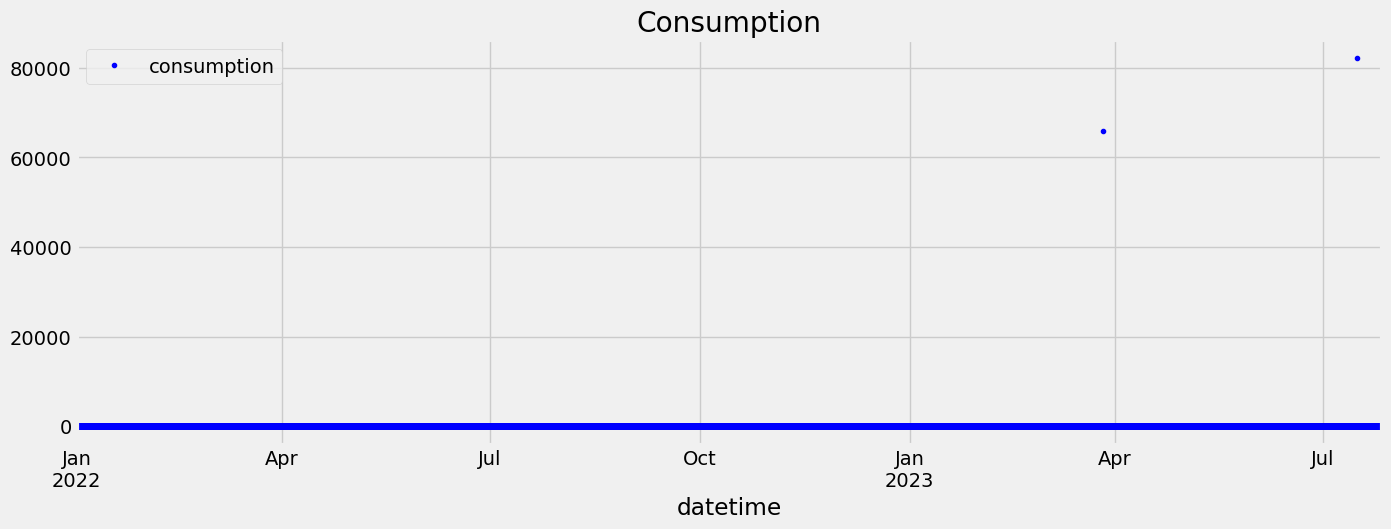

In [32]:
df.plot(style='.', figsize=(15, 5), color='blue', title='Consumption')

<Axes: ylabel='Frequency'>

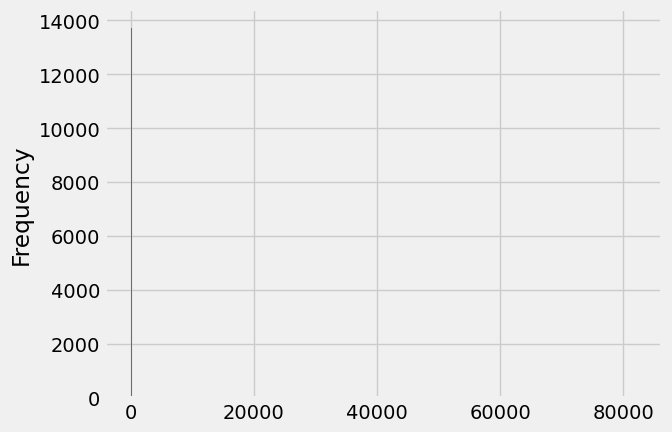

In [37]:
df['consumption'].plot(kind='hist', bins=500)

<Axes: xlabel='datetime'>

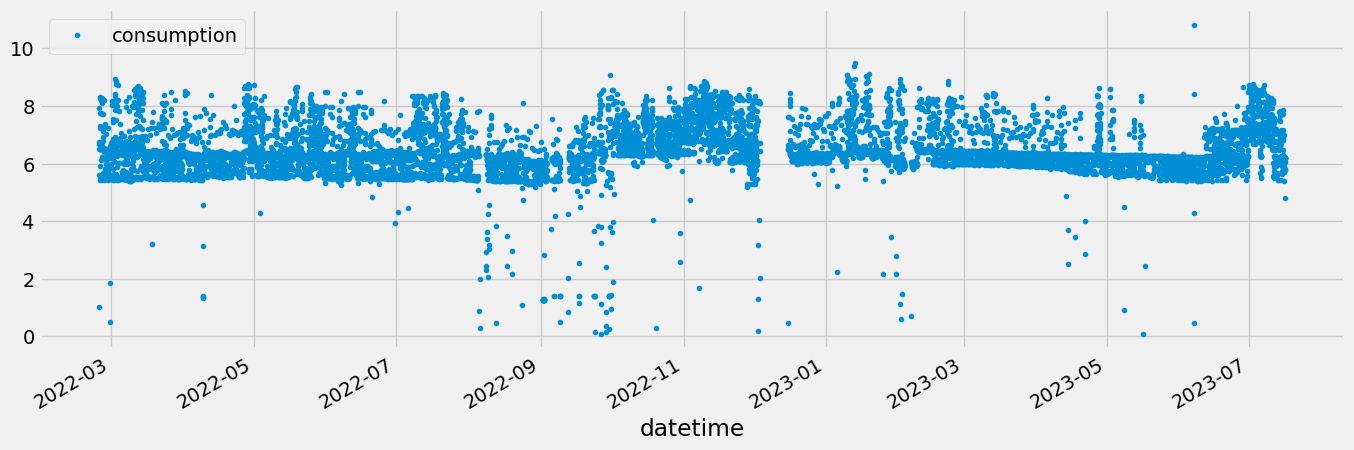

In [44]:
df.query('consumption > 0 and consumption < 40').plot(figsize=(15, 5), style='.')

In [45]:
# Create lag features for XGBoost
df['lag_1'] = df['consumption'].shift(1)
df['lag_2'] = df['consumption'].shift(2)
df['lag_3'] = df['consumption'].shift(3)
# You can create more lag features if needed


In [46]:
df.sample(100)

,consumption,lag_1,lag_2,lag_3
datetime,,,,
2022-12-31 11:00:00,6.066,6.080,6.084,6.066
2022-06-30 22:00:00,6.353,5.500,6.326,5.476
2022-01-29 11:00:00,0.000,0.000,0.000,0.000
2022-12-27 01:00:00,6.081,6.225,6.283,6.333
2023-03-14 04:00:00,5.969,6.289,6.367,6.352
...,...,...,...,...
2023-03-05 07:00:00,6.375,6.375,6.438,6.367
2023-02-05 21:00:00,0.000,0.000,0.000,0.000
2022-06-19 01:00:00,5.866,5.875,6.260,6.238


In [47]:
# Create rolling window features
df['rolling_mean_3'] = df['consumption'].rolling(window=3).mean()
df['rolling_std_3'] = df['consumption'].rolling(window=3).std()


In [48]:
df.sample(100)

,consumption,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
datetime,,,,,,
2022-08-15 20:00:00,6.219,6.218,5.417,6.235,5.951333,0.462747
2023-07-12 09:00:00,5.977,7.211,5.914,6.250,6.367333,0.731315
2022-04-28 08:00:00,8.076,7.310,7.954,7.805,7.780000,0.411577
2023-03-13 18:00:00,5.977,7.820,6.820,8.344,6.872333,0.922614
2022-07-07 03:00:00,5.483,6.348,5.497,6.330,5.776000,0.495416
...,...,...,...,...,...,...
2023-04-10 11:00:00,7.664,6.266,6.000,5.844,6.643333,0.893873
2023-04-18 01:00:00,6.305,5.890,5.790,6.289,5.995000,0.273084
2022-12-31 06:00:00,6.249,6.261,6.288,6.283,6.266000,0.019975


In [56]:
# Extract datetime features from the index
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month

# Define features and target
X = df[['lag_1', 'lag_2', 'lag_3', 'hour', 'day', 'month']]
y = df['consumption']

In [57]:
df.sample(100)

,consumption,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,hour,day,month
datetime,,,,,,,,,
2023-03-27 02:00:00,6.328,6.219,5.937,5.922,6.161333,0.201777,2,27,3
2022-01-13 15:00:00,0.000,0.000,0.000,0.000,0.000000,0.000000,15,13,1
2022-10-17 21:00:00,6.706,6.657,6.933,7.129,6.765333,0.147256,21,17,10
2022-01-31 05:00:00,0.000,0.000,0.000,0.000,0.000000,0.000000,5,31,1
2022-07-18 10:00:00,6.206,6.470,5.505,7.606,6.060333,0.498719,10,18,7
...,...,...,...,...,...,...,...,...,...
2022-04-02 15:00:00,5.575,6.332,7.366,8.444,6.424333,0.899063,15,2,4
2023-05-08 14:00:00,0.930,6.218,6.274,6.078,4.474000,3.069322,14,8,5
2023-02-08 21:00:00,6.461,6.480,6.481,6.210,6.474000,0.011269,21,8,2
